# 13 — Naive Bayes (Gaussian) (Classification Track — Part A)
**23CSE301 Machine Learning — Capstone, Review 1**

**Dataset:** Employee promotion (`train.csv`) **Target:** `is_promoted` (1 = promoted, 0 = not promoted)

| Block | Rubric section |
|---|---|
| 1 | Section A — Dataset & EDA |
| 2 | Section B — Preprocessing & Feature Engineering |
| 3 | Section D — Classification Track, Part A (Gaussian Naive Bayes) |

Naive Bayes applies **Bayes' theorem** to get P(promoted | features). It is called *naive* because it assumes every feature is **conditionally independent** of the others given the class, which lets it multiply simple per-feature probabilities instead of modelling their interactions. The Gaussian version assumes each numeric feature follows a **normal distribution** within each class. It trains in a fraction of a second, which makes it a useful speed/accuracy baseline.

---
# BLOCK 1 — Dataset & EDA (Section A)

In [1]:
# ============================================================
# BLOCK 1 : DATASET & EDA
# ============================================================

# ---- 1.0 Imports & global settings ----
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42                      # fixed seed for reproducibility (guideline 7.1)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")   # colour-blind-friendly palette (guideline 7.3)
pd.set_option("display.max_columns", 50)

DATA_PATH = "../data/train.csv"        # change if your file is somewhere else
TARGET = "is_promoted"

**Note on the dataset files:** the original download has `train.csv` (labelled) and `test.csv` (**no `is_promoted` column**).
Because the test file has no labels, it cannot be used to measure accuracy, so all 5 classifiers use `train.csv`
split 80:20 with stratification.

## A1 — Dataset loading & audit

In [2]:
# ---- 1.1 Load the dataset ----
df = pd.read_csv(DATA_PATH)

# employee_id is a unique identifier, not a predictive feature -> drop it
df = df.drop(columns=["employee_id"], errors="ignore")

# strip stray spaces from text columns
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].astype("object").where(df[col].isna(), df[col].astype(str).str.strip())

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (54808, 12)


,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [3]:
# ---- 1.2 Data types, missing values & duplicates ----
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_%": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
print("Duplicate rows:", df.duplicated().sum())
audit

Duplicate rows: 219


,dtype,missing_count,missing_%,n_unique
department,object,0,0.00,9
region,object,0,0.00,34
education,object,2409,4.40,3
gender,object,0,0.00,2
recruitment_channel,object,0,0.00,3
no_of_trainings,int64,0,0.00,10
age,int64,0,0.00,41
previous_year_rating,float64,4124,7.52,5
length_of_service,int64,0,0.00,35
awards_won?,int64,0,0.00,2


In [4]:
# ---- 1.3 Statistical summary of numeric columns ----
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_trainings,54808.0,1.253011,0.609264,1.0,1.0,1.0,1.0,10.0
age,54808.0,34.803915,7.660169,20.0,29.0,33.0,39.0,60.0
previous_year_rating,50684.0,3.329256,1.259993,1.0,3.0,3.0,4.0,5.0
length_of_service,54808.0,5.865512,4.265094,1.0,3.0,5.0,7.0,37.0
awards_won?,54808.0,0.023172,0.150450,0.0,0.0,0.0,0.0,1.0
avg_training_score,54808.0,63.386750,13.371559,39.0,51.0,60.0,76.0,99.0
is_promoted,54808.0,0.085170,0.279137,0.0,0.0,0.0,0.0,1.0


is_promoted
0    50140
1     4668
Name: count, dtype: int64

Class balance (%):
is_promoted
0    91.48
1     8.52
Name: proportion, dtype: float64

Imbalance ratio  ->  1 promoted for every 10.7 not promoted


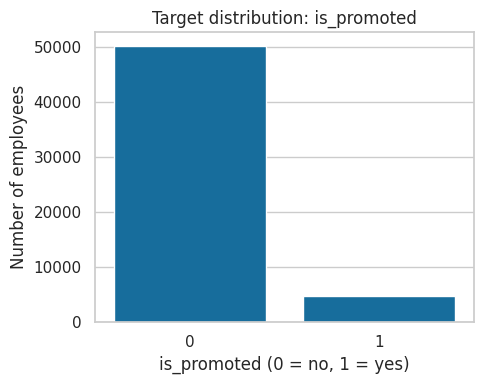

In [5]:
# ---- 1.4 Class distribution of the target (class imbalance check) ----
counts = df[TARGET].value_counts().sort_index()
print(counts)
print("\nClass balance (%):")
print((df[TARGET].value_counts(normalize=True) * 100).round(2))
print("\nImbalance ratio  ->  1 promoted for every %.1f not promoted" % (counts[0] / counts[1]))

plt.figure(figsize=(5, 4))
sns.countplot(x=df[TARGET])
plt.title("Target distribution: is_promoted")
plt.xlabel("is_promoted (0 = no, 1 = yes)"); plt.ylabel("Number of employees")
plt.tight_layout(); plt.show()

**📝 What this shows:** Only 8.5% of employees were promoted, so a model that says 'nobody is promoted' would already be 91.5% accurate.

## A2 — EDA visualisations

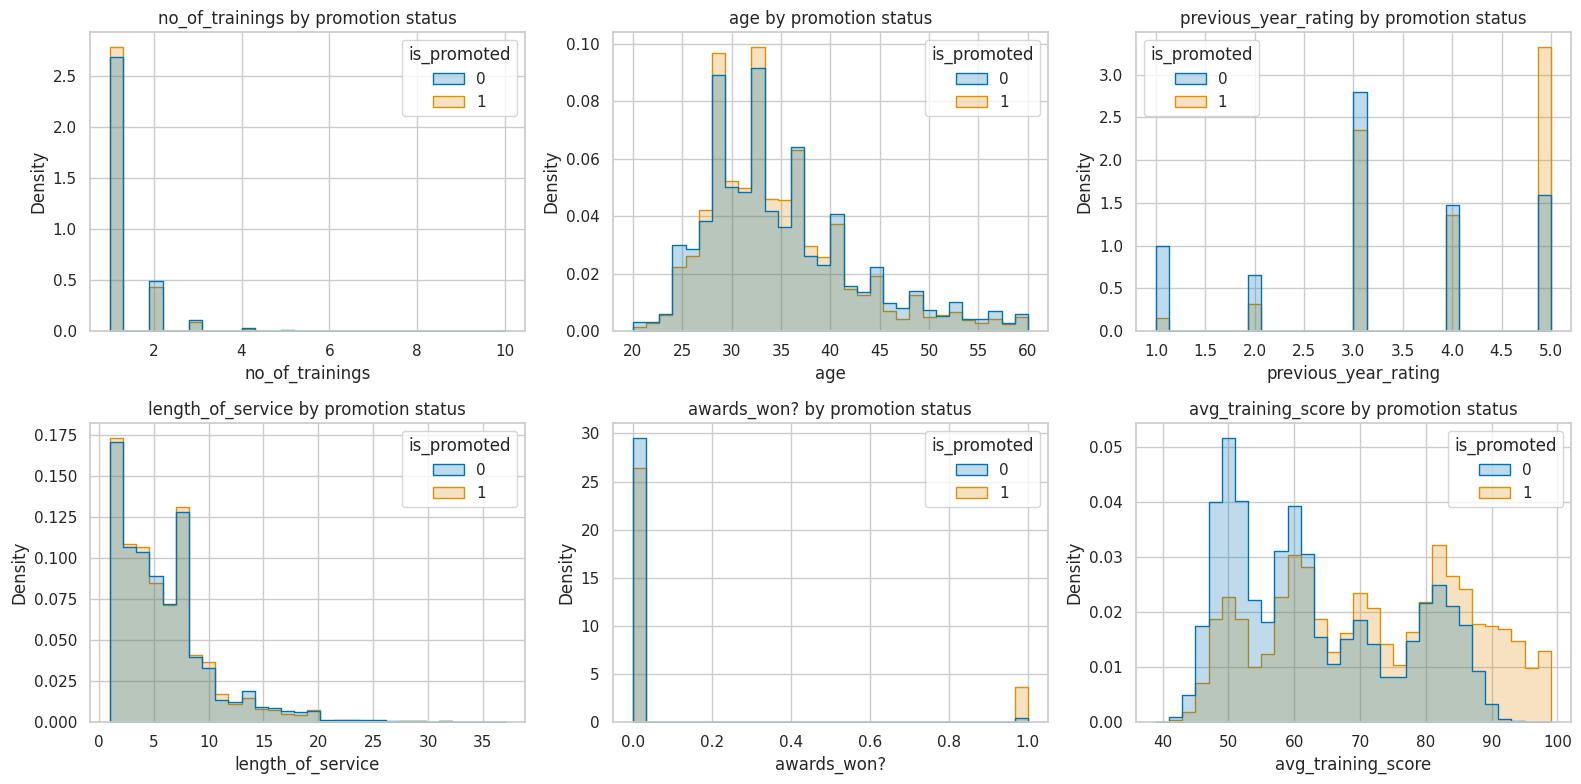

In [6]:
# ---- 1.5 Distribution of EACH numeric feature, split by class ----
num_features = ["no_of_trainings", "age", "previous_year_rating", "length_of_service",
                "awards_won?", "avg_training_score"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_features):
    sns.histplot(data=df, x=col, hue=TARGET, bins=30, element="step", stat="density",
                 common_norm=False, ax=ax)
    ax.set_title(f"{col} by promotion status")
    ax.set_xlabel(col); ax.set_ylabel("Density")
plt.tight_layout(); plt.show()

**📝 What this shows:** Promoted employees have a much higher training score (71 vs 63) and far more awards; age and service length look the same for both groups.

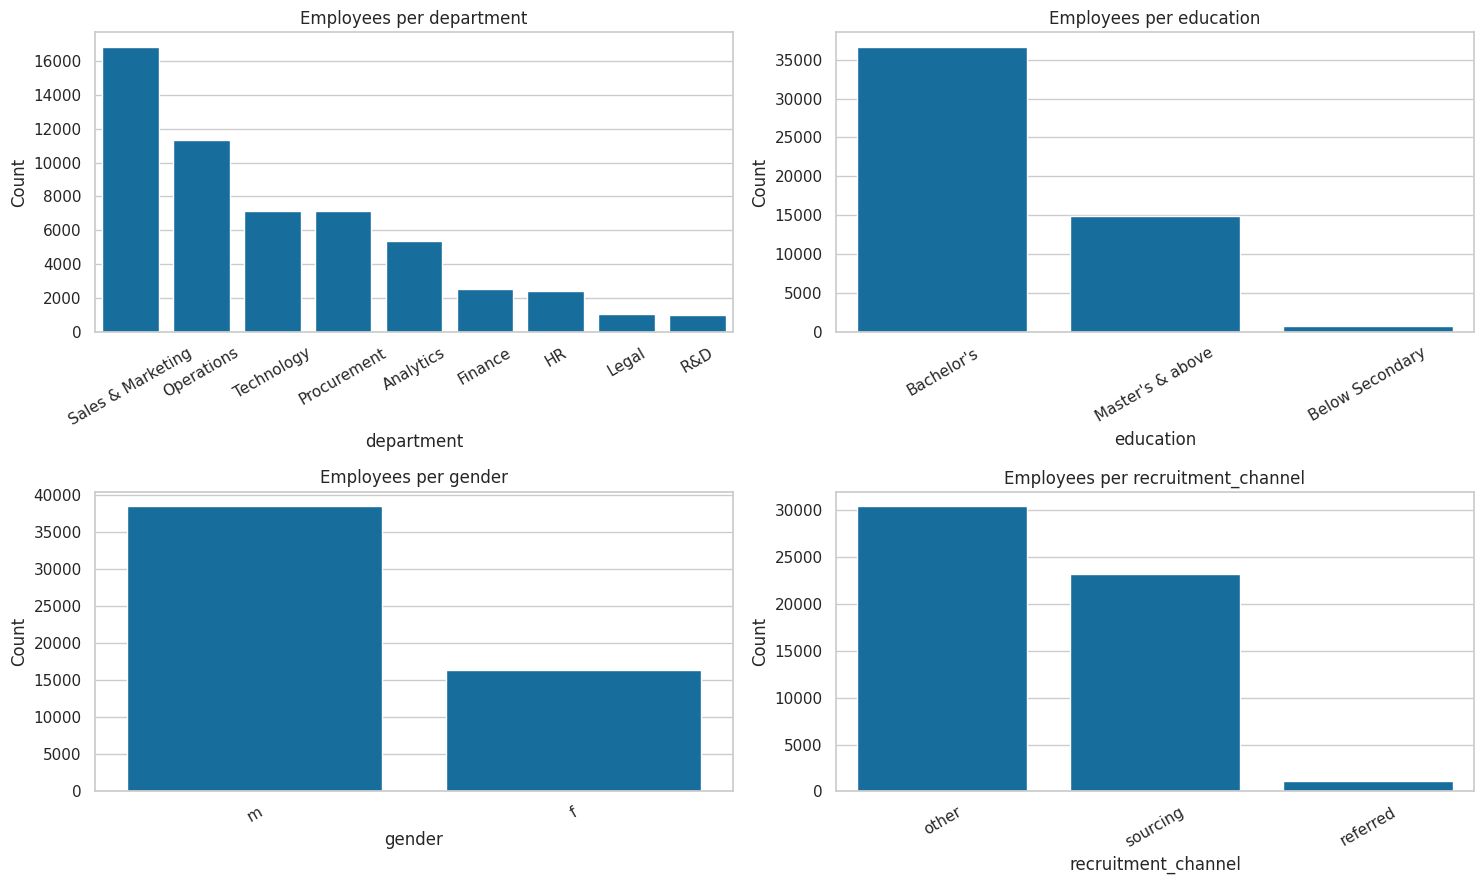

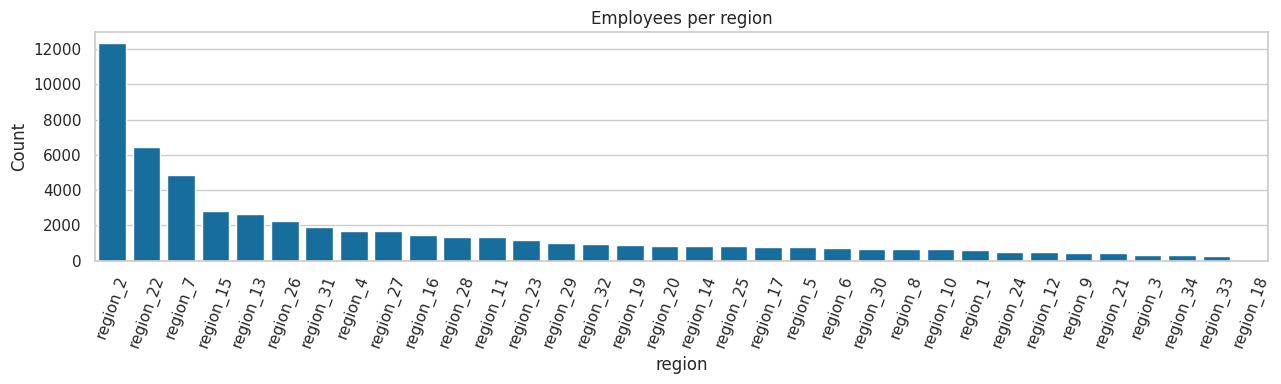

In [7]:
# ---- 1.6 Distribution of EACH categorical feature ----
cat_features = ["department", "region", "education", "gender", "recruitment_channel"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.flat, ["department", "education", "gender", "recruitment_channel"]):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(f"Employees per {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

plt.figure(figsize=(13, 4))
sns.countplot(data=df, x="region", order=df["region"].value_counts().index)
plt.title("Employees per region"); plt.xlabel("region"); plt.ylabel("Count"); plt.xticks(rotation=70)
plt.tight_layout(); plt.show()

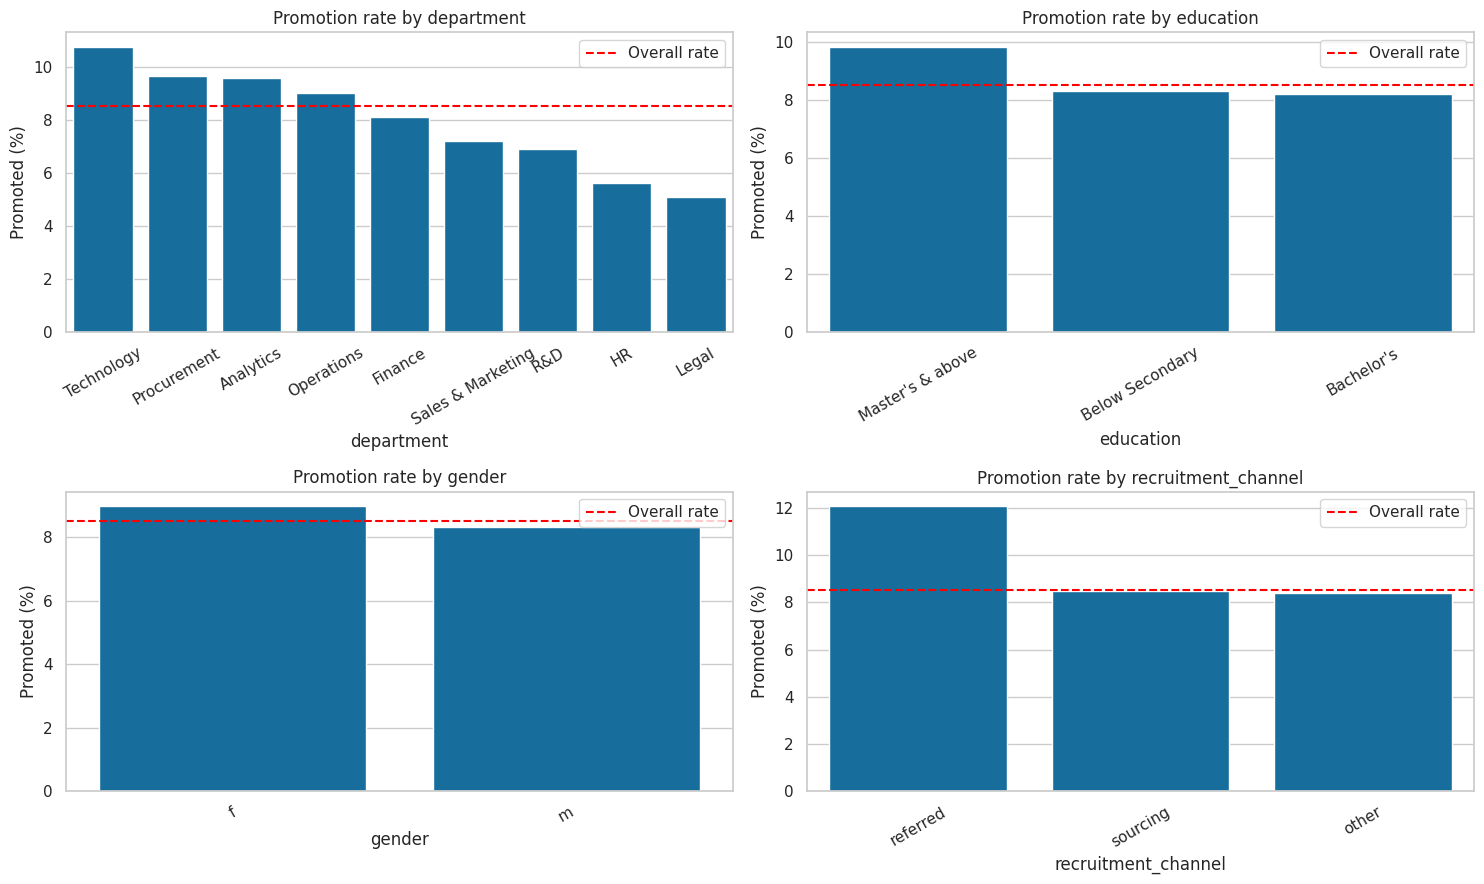

In [8]:
# ---- 1.7 Promotion RATE per category (the class distribution within each group) ----
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.flat, ["department", "education", "gender", "recruitment_channel"]):
    rate = df.groupby(col, dropna=False)[TARGET].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax)
    ax.axhline(df[TARGET].mean() * 100, color="red", linestyle="--", label="Overall rate")
    ax.set_title(f"Promotion rate by {col}")
    ax.set_xlabel(col); ax.set_ylabel("Promoted (%)"); ax.tick_params(axis="x", rotation=30); ax.legend()
plt.tight_layout(); plt.show()

**📝 What this shows:** Technology promotes the most (10.8%) and Legal the least (5.1%), and referred employees do best at 12.1%.

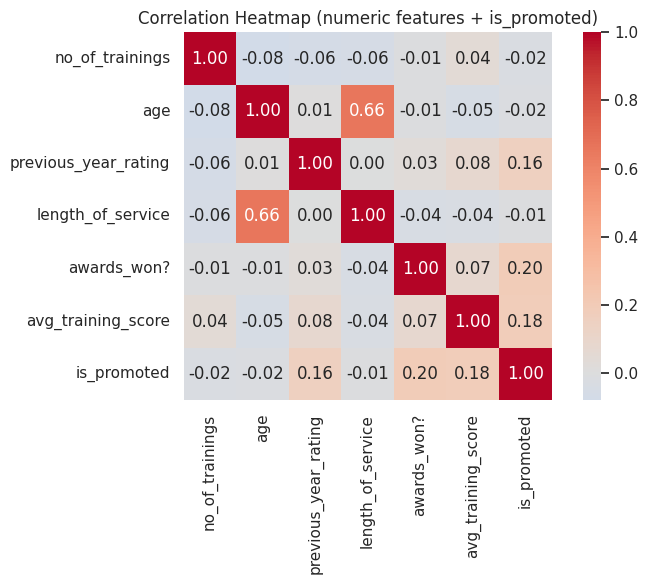

In [9]:
# ---- 1.8 Correlation heatmap (numeric features + target) ----
plt.figure(figsize=(8, 6))
corr = df[num_features + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (numeric features + is_promoted)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Awards (0.196) and training score (0.181) link most to promotion, but all links are weak; age and service length are strongly tied to each other (0.66).

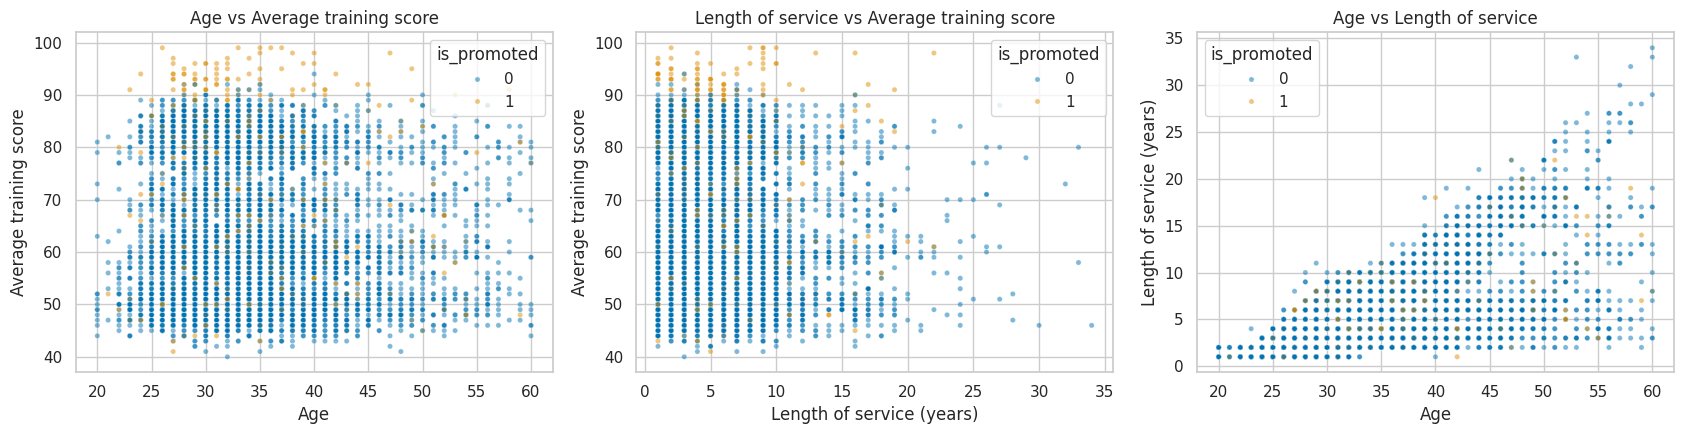

In [10]:
# ---- 1.9 Scatter plots: feature relationships coloured by the target ----
sample = df.sample(6000, random_state=RANDOM_STATE)     # sample so the plots stay readable

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.scatterplot(data=sample, x="age", y="avg_training_score", hue=TARGET, alpha=0.5, s=14, ax=axes[0])
axes[0].set_title("Age vs Average training score")
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Average training score")

sns.scatterplot(data=sample, x="length_of_service", y="avg_training_score", hue=TARGET, alpha=0.5, s=14, ax=axes[1])
axes[1].set_title("Length of service vs Average training score")
axes[1].set_xlabel("Length of service (years)"); axes[1].set_ylabel("Average training score")

sns.scatterplot(data=sample, x="age", y="length_of_service", hue=TARGET, alpha=0.5, s=14, ax=axes[2])
axes[2].set_title("Age vs Length of service")
axes[2].set_xlabel("Age"); axes[2].set_ylabel("Length of service (years)")
plt.tight_layout(); plt.show()

**📝 What this shows:** The two groups overlap almost completely, and only training score separates them, with promoted people sitting near the top.

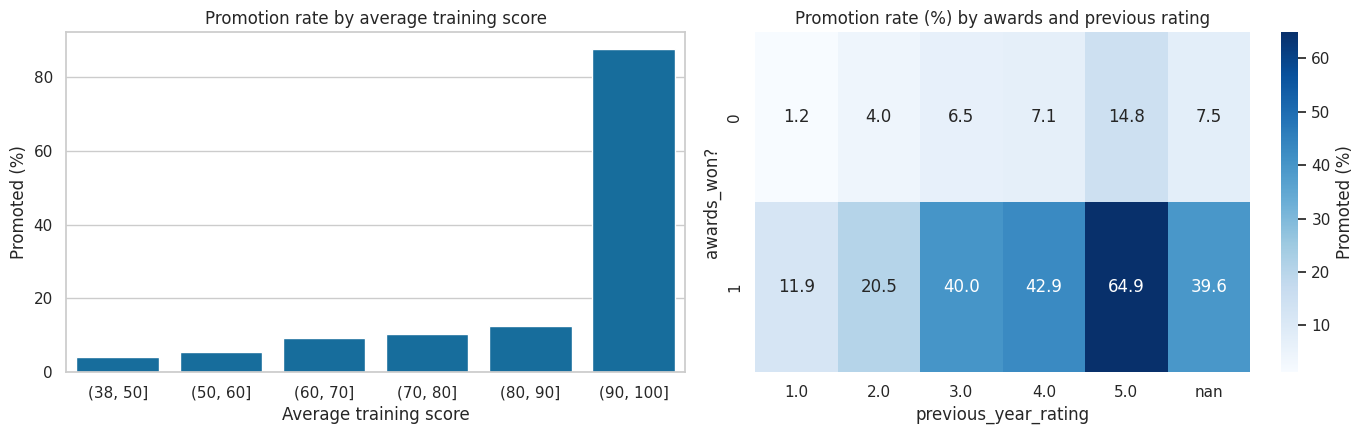

In [11]:
# ---- 1.10 Promotion rate by training score and by awards ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
score_bins = pd.cut(df["avg_training_score"], bins=[38, 50, 60, 70, 80, 90, 100])
rate = df.groupby(score_bins, observed=True)[TARGET].mean() * 100
sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[0])
axes[0].set_title("Promotion rate by average training score")
axes[0].set_xlabel("Average training score"); axes[0].set_ylabel("Promoted (%)")

rate2 = df.groupby(["awards_won?", "previous_year_rating"], dropna=False)[TARGET].mean().unstack() * 100
sns.heatmap(rate2, annot=True, fmt=".1f", cmap="Blues", ax=axes[1], cbar_kws={"label": "Promoted (%)"})
axes[1].set_title("Promotion rate (%) by awards and previous rating")
axes[1].set_xlabel("previous_year_rating"); axes[1].set_ylabel("awards_won?")
plt.tight_layout(); plt.show()

**📝 What this shows:** Scoring above 90 gives an 87.7% promotion rate, and an award plus a rating of 5 gives 64.9%.

---
# BLOCK 2 — Preprocessing & Feature Engineering (Section B)

In [12]:
# ============================================================
# BLOCK 2 : PREPROCESSING & FEATURE ENGINEERING
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# ---- 2.1 Remove duplicate rows ----
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {before - len(df)}  ->  rows now: {len(df)}")

# ---- 2.2 Understand the missing values before deciding a strategy ----
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# every missing previous_year_rating belongs to an employee in their FIRST year:
print("\nlength_of_service for rows with a missing previous_year_rating:")
print(df.loc[df["previous_year_rating"].isnull(), "length_of_service"].value_counts().head())

# is the missing education informative? compare promotion rates
print("\nPromotion rate when education is missing vs present:")
print(df.groupby(df["education"].isnull())[TARGET].mean().round(4))

Duplicates removed: 219  ->  rows now: 54589

Missing values:
education               2391
previous_year_rating    4013
dtype: int64

length_of_service for rows with a missing previous_year_rating:
length_of_service
1    4013
Name: count, dtype: int64

Promotion rate when education is missing vs present:
education
False    0.087
True     0.051
Name: is_promoted, dtype: float64


**Missing-value strategy (justified):**

| Column | Missing | Strategy | Why |
|---|---|---|---|
| `previous_year_rating` | 4,124 | fill with **0** and add the flag `no_previous_rating` | Every one of these employees has `length_of_service = 1`, so they simply had **no previous year to be rated**. 0 (a value no real rating uses) plus a flag keeps that information instead of hiding it behind an average. |
| `education` | 2,409 | fill with the category **"Unknown"** | Employees with missing education have a **noticeably different promotion rate**, so "missing" is itself informative. Replacing it with the most common value would destroy that signal. |

In [13]:
# ---- 2.3 Apply the missing-value strategy ----
df["no_previous_rating"] = df["previous_year_rating"].isnull().astype(int)   # flag column
df["previous_year_rating"] = df["previous_year_rating"].fillna(0)
df["education"] = df["education"].fillna("Unknown")

print("Missing values now:", int(df.isnull().sum().sum()))

Missing values now: 0


## B3 — Feature engineering

In [14]:
# ---- 2.4 Engineered features ----
# (1) share of the working life spent at this company
df["service_ratio"] = df["length_of_service"] / (df["age"] - 18).clip(lower=1)

# (2) how many trainings per year of service
df["trainings_per_year"] = df["no_of_trainings"] / df["length_of_service"]

# (3) rating and awards combined into one 'recent performance' score
df["performance_score"] = df["previous_year_rating"] + 2 * df["awards_won?"]

engineered = ["service_ratio", "trainings_per_year", "performance_score"]
df.groupby(TARGET)[engineered].mean().round(3)

,service_ratio,trainings_per_year,performance_score
is_promoted,,,
0,0.344,0.372,3.056
1,0.344,0.357,3.938


**Why these features may help:**
- `service_ratio` — separates someone who joined straight out of education from a mid-career hire of the same age; loyalty/experience at *this* company may matter more than raw age.
- `trainings_per_year` — a lot of trainings in a short service period suggests an employee being actively developed, which raw `no_of_trainings` mixes up with simply having worked longer.
- `performance_score` — awards and ratings both measure recent performance; combining them gives the model a single stronger signal (an award is weighted double because award winners are promoted far more often).

*(A 4th feature, `score_vs_dept_avg`, is built after the split in cell 2.7 because it needs statistics from the training set only.)*

## B2 — Stratified train/test split, encoding & scaling

In [15]:
# ---- 2.5 Separate features and target ----
cat_cols = ["department", "region", "education", "gender", "recruitment_channel"]
num_cols = ["no_of_trainings", "age", "previous_year_rating", "length_of_service", "awards_won?",
            "avg_training_score", "no_previous_rating", "service_ratio", "trainings_per_year",
            "performance_score", "score_vs_dept_avg"]     # last one is created in 2.7

X = df[cat_cols + [c for c in num_cols if c != "score_vs_dept_avg"]]
y = df[TARGET]

# ---- 2.6 Stratified 80:20 split ----
# stratify=y keeps the same 8.5% promotion rate in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_test = X_train.copy(), X_test.copy()
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Promotion rate  train: %.4f | test: %.4f" % (y_train.mean(), y_test.mean()))

Train: (43671, 15)  Test: (10918, 15)
Promotion rate  train: 0.0855 | test: 0.0855


In [16]:
# ---- 2.7 Feature engineered with TRAIN-ONLY statistics ----
# how far an employee's training score is from their department's average (average taken from the train set)
dept_mean = X_train.groupby("department")["avg_training_score"].mean()
overall_mean = X_train["avg_training_score"].mean()

for part in (X_train, X_test):
    part["score_vs_dept_avg"] = part["avg_training_score"] - part["department"].map(dept_mean).fillna(overall_mean)

print(X_train[["avg_training_score", "score_vs_dept_avg"]].describe().T.round(2))

                      count   mean    std    min    25%    50%    75%    max
avg_training_score  43671.0  63.41  13.38  39.00  51.00  60.00  76.00  99.00
score_vs_dept_avg   43671.0  -0.00   4.61 -11.96  -2.27  -0.27   1.73  48.73


In [17]:
# ---- 2.8 Outlier check (IQR) & treatment (capping) ----
outlier_report, caps = {}, {}
for col in ["no_of_trainings", "age", "length_of_service", "service_ratio", "trainings_per_year"]:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_report[col] = int(((X_train[col] < low) | (X_train[col] > high)).sum())
    caps[col] = (X_train[col].quantile(0.01), X_train[col].quantile(0.99))   # train-derived limits

print("IQR outliers in train set:")
print(pd.Series(outlier_report))

for col, (lo, hi) in caps.items():
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col] = X_test[col].clip(lo, hi)     # the same train limits are applied to test

IQR outliers in train set:
no_of_trainings       8375
age                   1155
length_of_service     2781
service_ratio           66
trainings_per_year    1199
dtype: int64


**Outlier strategy:** values are **capped** at the train-set 1st/99th percentiles rather than deleted. Extreme cases
(e.g. 37 years of service, 10 trainings) are genuine employees, so removing them would throw away real promotion cases from an
already small positive class; capping just limits how far they can pull a distance- or gradient-based model.

In [18]:
# ---- 2.9 Encoding + scaling (fitted on TRAIN only -> no data leakage) ----
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),                                              # scale numeric features
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),   # one-hot encode categoricals
])

X_train_p = preprocessor.fit_transform(X_train)    # FIT + transform on train
X_test_p = preprocessor.transform(X_test)          # ONLY transform on test

feature_names = preprocessor.get_feature_names_out()
print("Processed train shape:", X_train_p.shape)
print("Processed test shape :", X_test_p.shape)
print("Positive class in train: %d (%.2f%%)" % (y_train.sum(), 100 * y_train.mean()))

Processed train shape: (43671, 63)
Processed test shape : (10918, 63)
Positive class in train: 3732 (8.55%)


**Handling the class imbalance:** only ~8.5% of employees were promoted. Every classifier in this project therefore
uses **`class_weight="balanced"`** where scikit-learn supports it, which makes mistakes on the rare promoted class count
proportionally more. Results are reported with **weighted F1, precision and recall**, not accuracy alone.

---
# BLOCK 3 — Classification Track Part A: Gaussian Naive Bayes (Section D)

In [19]:
# ============================================================
# BLOCK 3 : CLASSIFICATION — GAUSSIAN NAIVE BAYES
# ============================================================
import time
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve, brier_score_loss)
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # keeps the 8.5% rate in every fold

def classification_metrics(y_true, y_hat, scores=None):
    # accuracy + weighted metrics (rubric D2) + metrics for the rare 'promoted' class
    out = {
        "Accuracy": accuracy_score(y_true, y_hat),
        "F1_weighted": f1_score(y_true, y_hat, average="weighted"),
        "Precision_weighted": precision_score(y_true, y_hat, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_hat, average="weighted"),
        "F1_promoted": f1_score(y_true, y_hat, pos_label=1, zero_division=0),
        "Recall_promoted": recall_score(y_true, y_hat, pos_label=1),
    }
    if scores is not None:
        out["ROC_AUC"] = roc_auc_score(y_true, scores)
    return out

# ---- 3.1 Train a default GaussianNB ----
start = time.time()
nb_default = GaussianNB()
nb_default.fit(X_train_p, y_train)
print(f"Training time: {time.time() - start:.3f} s on {len(X_train_p)} rows   <- compare this with SVC or Random Forest")

# ---- 3.2 Predictions ----
y_pred_default = nb_default.predict(X_test_p)
y_proba_default = nb_default.predict_proba(X_test_p)[:, 1]
print("Predicted promotions:", int(y_pred_default.sum()), "| actual promotions:", int(y_test.sum()))
print("Class priors learned from the training data:", np.round(nb_default.class_prior_, 4))

default_scores = classification_metrics(y_test, y_pred_default, y_proba_default)
pd.DataFrame([default_scores], index=["GaussianNB (default)"]).round(4)

Training time: 0.034 s on 43671 rows   <- compare this with SVC or Random Forest
Predicted promotions: 7966 | actual promotions: 933
Class priors learned from the training data: [0.9145 0.0855]


,Accuracy,F1_weighted,Precision_weighted,Recall_weighted,F1_promoted,Recall_promoted,ROC_AUC
GaussianNB (default),0.3342,0.4163,0.8867,0.3342,0.1832,0.8735,0.739


**📝 What this shows:** Its accuracy is only 33%, because it wrongly flags 7,966 of 10,918 employees as promotions.

## Checking the two assumptions Naive Bayes makes

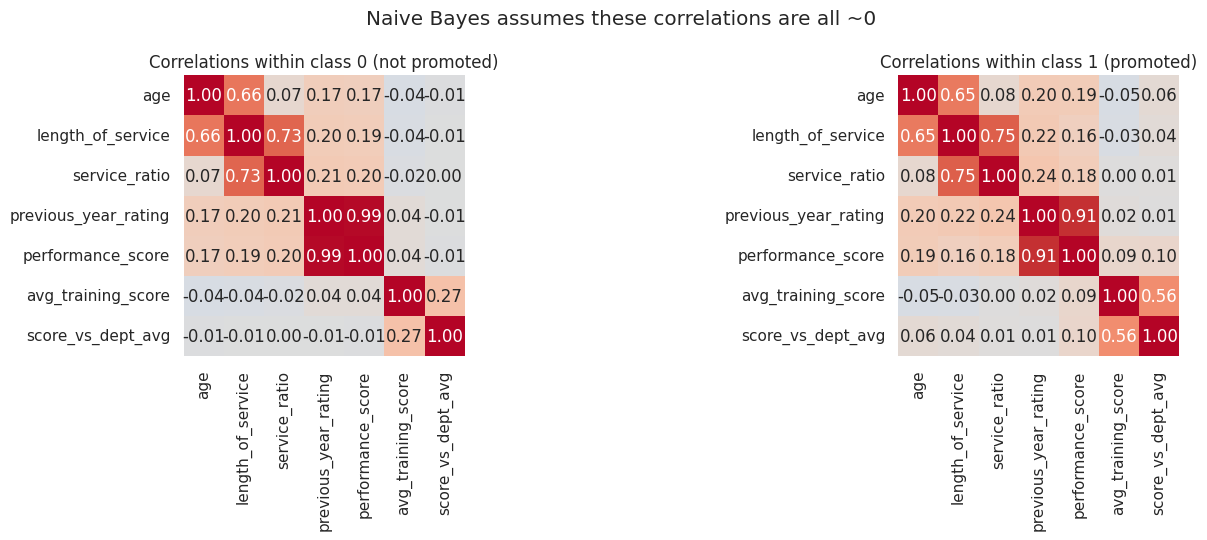

Largest within-class correlations (class 0):
performance_score     previous_year_rating    0.987
previous_year_rating  performance_score       0.987
length_of_service     service_ratio           0.733
service_ratio         length_of_service       0.733
dtype: float64


In [20]:
# ---- 3.3 Assumption 1: are the features conditionally independent? ----
# If the assumption held, the correlations between features WITHIN each class would all be near zero.
check_cols = ["age", "length_of_service", "service_ratio", "previous_year_rating",
              "performance_score", "avg_training_score", "score_vs_dept_avg"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, cls in zip(axes, [0, 1]):
    corr = X_train.loc[y_train == cls, check_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax, cbar=False)
    ax.set_title(f"Correlations within class {cls} ({'promoted' if cls else 'not promoted'})")
plt.suptitle("Naive Bayes assumes these correlations are all ~0")
plt.tight_layout(); plt.show()

off_diag = lambda c: c.where(~np.eye(len(c), dtype=bool)).abs().stack()
print("Largest within-class correlations (class 0):")
print(off_diag(X_train.loc[y_train == 0, check_cols].corr()).sort_values(ascending=False).head(4).round(3))

**📝 What this shows:** Two features are almost copies of each other (0.987), so the model counts the same evidence twice.

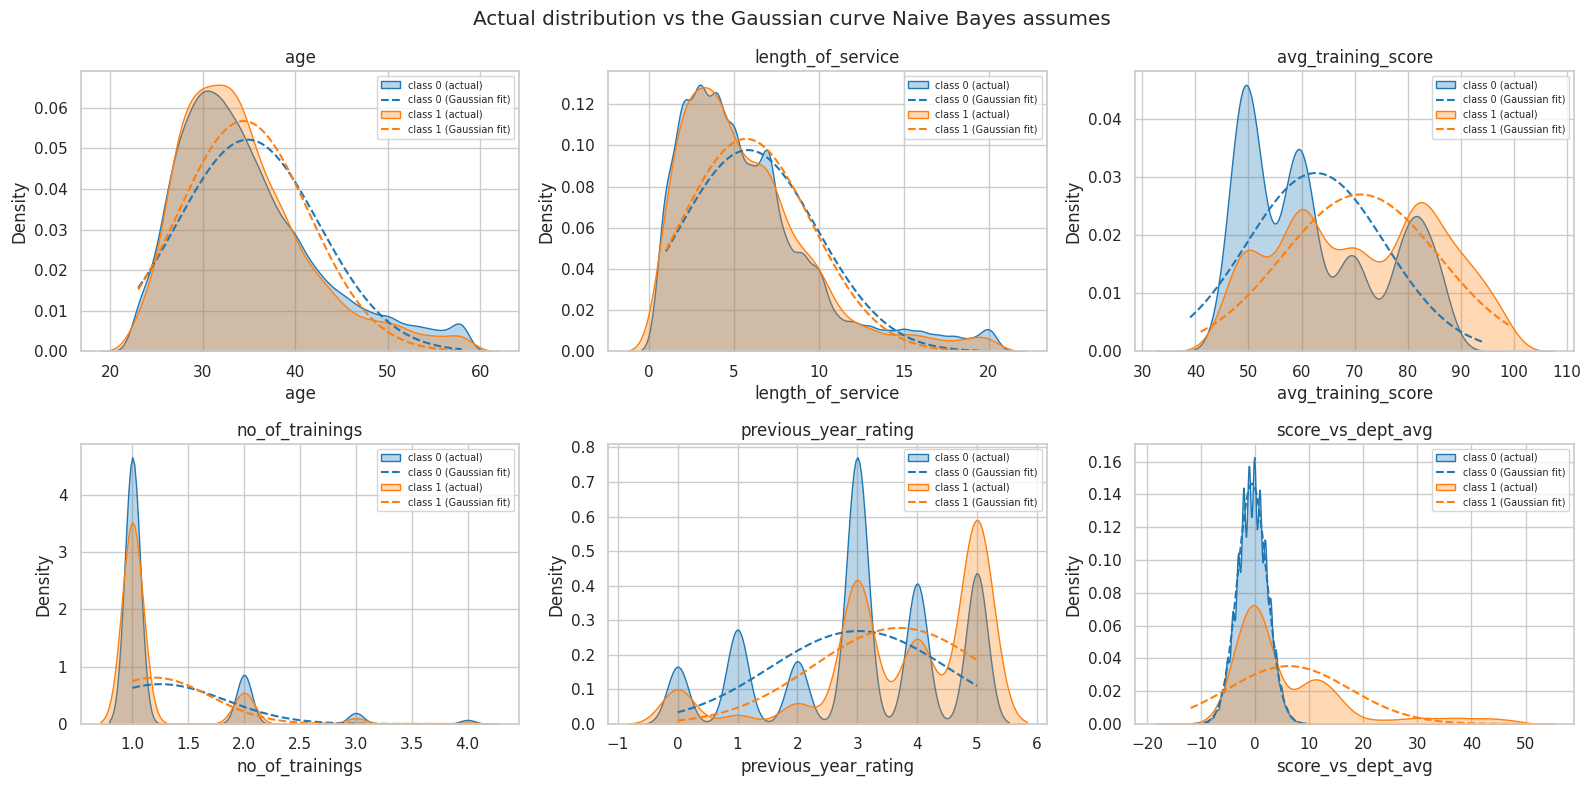

In [21]:
# ---- 3.4 Assumption 2: are the numeric features Gaussian (bell-shaped) within each class? ----
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, ["age", "length_of_service", "avg_training_score",
                               "no_of_trainings", "previous_year_rating", "score_vs_dept_avg"]):
    for cls, colour in [(0, "tab:blue"), (1, "tab:orange")]:
        vals = X_train.loc[y_train == cls, col]
        sns.kdeplot(vals, ax=ax, color=colour, fill=True, alpha=0.3,
                    label=f"class {cls} (actual)")
        xs = np.linspace(vals.min(), vals.max(), 200)
        gauss = np.exp(-0.5 * ((xs - vals.mean()) / max(vals.std(), 1e-9)) ** 2) / (vals.std() * np.sqrt(2 * np.pi))
        ax.plot(xs, gauss, "--", color=colour, label=f"class {cls} (Gaussian fit)")
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel("Density")
    ax.legend(fontsize=7)
plt.suptitle("Actual distribution vs the Gaussian curve Naive Bayes assumes")
plt.tight_layout(); plt.show()

**📝 What this shows:** Most features are not bell-shaped at all, especially the 0/1 columns, yet the model still works reasonably.

## Hyperparameter tuning (`var_smoothing`) and feature-set choice

GaussianNB has essentially one hyperparameter: **`var_smoothing`**, a small value added to every feature's variance to stop
near-constant features (such as one-hot columns that are almost always 0) from producing extreme probabilities.
We also test which **feature set** suits the Gaussian assumption best, and a **BernoulliNB** variant that models
the 0/1 one-hot columns properly.

Best parameters : {'var_smoothing': 0.1}
Best CV F1 (promoted class): 0.4861


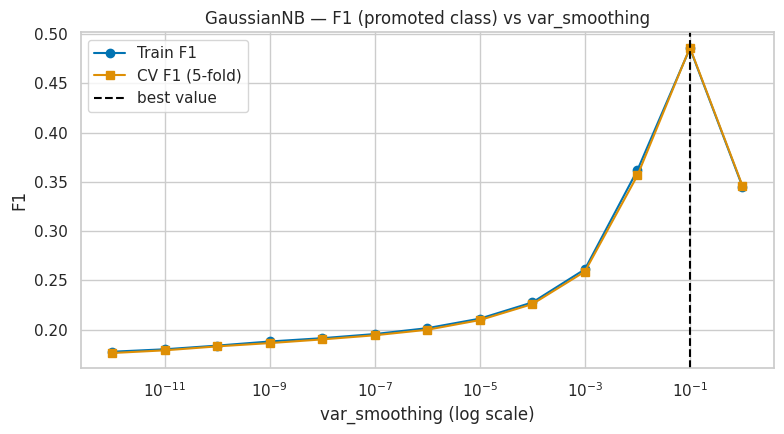

,param_var_smoothing,mean_test_score,std_test_score
0,0.0000,0.1764,0.0020
1,0.0000,0.1791,0.0024
2,0.0000,0.1831,0.0017
3,0.0000,0.1865,0.0010
4,0.0000,0.1902,0.0012
5,0.0000,0.1944,0.0016
6,0.0000,0.2000,0.0019
7,0.0000,0.2098,0.0027
8,0.0001,0.2260,0.0034
9,0.0010,0.2590,0.0067


In [22]:
# ---- 3.5 GridSearchCV over var_smoothing ----
param_grid = {"var_smoothing": np.logspace(-12, 0, 13)}
grid = GridSearchCV(GaussianNB(), param_grid, cv=skf, scoring="f1", n_jobs=-1, return_train_score=True)
grid.fit(X_train_p, y_train)

best_params = {"var_smoothing": float(grid.best_params_["var_smoothing"])}
print("Best parameters :", best_params)
print("Best CV F1 (promoted class): %.4f" % grid.best_score_)

cv_res = pd.DataFrame(grid.cv_results_)
plt.figure(figsize=(8, 4.5))
plt.semilogx(cv_res["param_var_smoothing"].astype(float), cv_res["mean_train_score"], "o-", label="Train F1")
plt.semilogx(cv_res["param_var_smoothing"].astype(float), cv_res["mean_test_score"], "s-", label="CV F1 (5-fold)")
plt.axvline(best_params["var_smoothing"], color="black", linestyle="--", label="best value")
plt.title("GaussianNB — F1 (promoted class) vs var_smoothing")
plt.xlabel("var_smoothing (log scale)"); plt.ylabel("F1")
plt.legend(); plt.tight_layout(); plt.show()
cv_res[["param_var_smoothing", "mean_test_score", "std_test_score"]].round(4)

**📝 What this shows:** The var_smoothing setting nearly triples the score (0.18 to 0.49), making it the most important setting in the project.

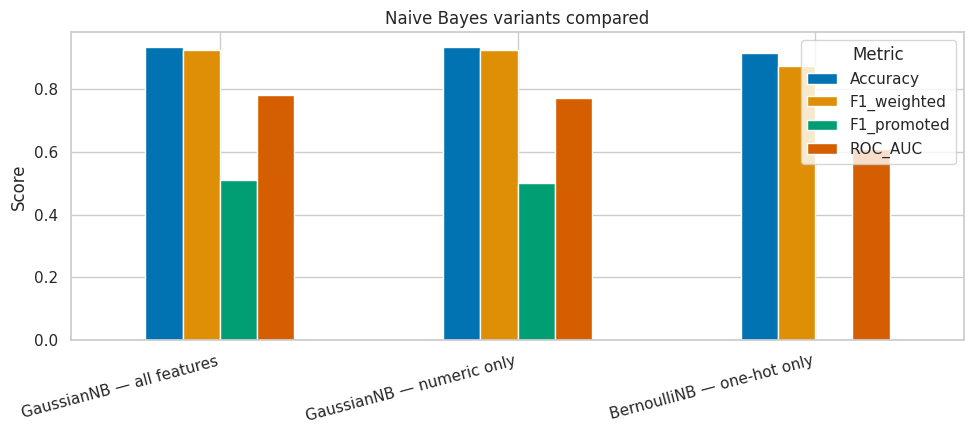

,Accuracy,F1_weighted,Precision_weighted,Recall_weighted,F1_promoted,Recall_promoted,ROC_AUC
variant,,,,,,,
GaussianNB — all features,0.9349,0.9264,0.9261,0.9349,0.5120,0.3998,0.7822
GaussianNB — numeric only,0.9345,0.9254,0.9255,0.9345,0.5017,0.3859,0.7735
BernoulliNB — one-hot only,0.9145,0.8737,0.8364,0.9145,0.0000,0.0000,0.6097


In [23]:
# ---- 3.6 Which feature set / NB variant works best? ----
num_slice = slice(0, len(num_cols))          # the first columns are the scaled numeric features
cat_slice = slice(len(num_cols), None)       # the rest are the one-hot columns

variants = {
    "GaussianNB — all features":        (GaussianNB(**best_params), X_train_p, X_test_p),
    "GaussianNB — numeric only":        (GaussianNB(**best_params), X_train_p[:, num_slice], X_test_p[:, num_slice]),
    "BernoulliNB — one-hot only":       (BernoulliNB(), X_train_p[:, cat_slice], X_test_p[:, cat_slice]),
}
variant_rows = []
for name, (model, Xtr, Xte) in variants.items():
    model.fit(Xtr, y_train)
    variant_rows.append({"variant": name,
                         **classification_metrics(y_test, model.predict(Xte), model.predict_proba(Xte)[:, 1])})
variant_df = pd.DataFrame(variant_rows).set_index("variant")

variant_df[["Accuracy", "F1_weighted", "F1_promoted", "ROC_AUC"]].plot(kind="bar", figsize=(10, 4.5))
plt.title("Naive Bayes variants compared")
plt.xlabel(""); plt.ylabel("Score"); plt.xticks(rotation=15, ha="right")
plt.legend(title="Metric"); plt.tight_layout(); plt.show()
variant_df.round(4)

**📝 What this shows:** Department and region alone predict no promotions at all, so the category columns carry almost no information.

In [24]:
# ---- 3.7 Final tuned model & improvement over the default ----
nb_best = GaussianNB(**best_params).fit(X_train_p, y_train)
y_pred = nb_best.predict(X_test_p)
y_proba = nb_best.predict_proba(X_test_p)[:, 1]
tuned_scores = classification_metrics(y_test, y_pred, y_proba)

compare = pd.DataFrame([default_scores, tuned_scores],
                       index=["GaussianNB default", f"GaussianNB tuned {best_params}"])
compare.loc["Improvement"] = compare.iloc[1] - compare.iloc[0]
compare.round(4)

,Accuracy,F1_weighted,Precision_weighted,Recall_weighted,F1_promoted,Recall_promoted,ROC_AUC
GaussianNB default,0.3342,0.4163,0.8867,0.3342,0.1832,0.8735,0.7390
GaussianNB tuned {'var_smoothing': 0.1},0.9349,0.9264,0.9261,0.9349,0.5120,0.3998,0.7822
Improvement,0.6007,0.5101,0.0394,0.6007,0.3288,-0.4737,0.0432


## D2 — Evaluation: accuracy, weighted F1 and confusion matrix

In [25]:
# ---- 3.8 Full classification report ----
print(classification_report(y_test, y_pred, target_names=["Not promoted (0)", "Promoted (1)"], digits=4))

                  precision    recall  f1-score   support

Not promoted (0)     0.9461    0.9849    0.9651      9985
    Promoted (1)     0.7118    0.3998    0.5120       933

        accuracy                         0.9349     10918
       macro avg     0.8290    0.6923    0.7386     10918
    weighted avg     0.9261    0.9349    0.9264     10918



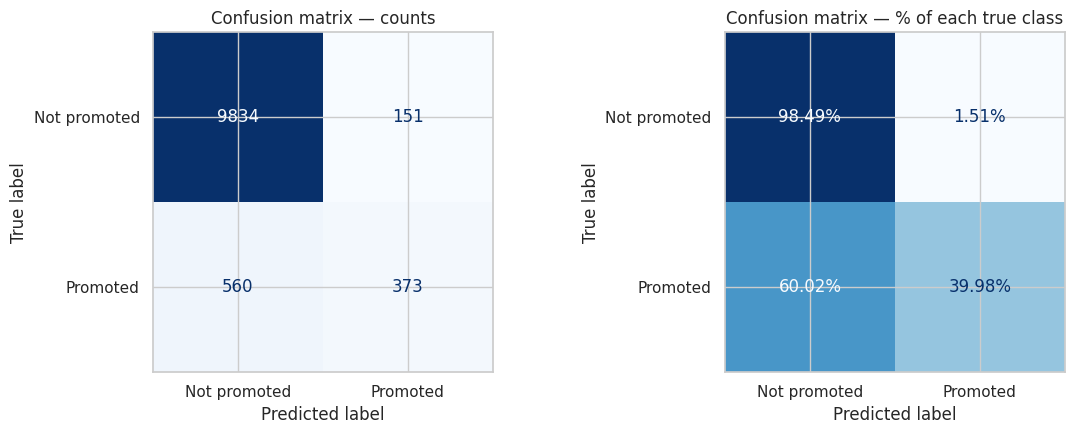

True promotions found (TP)   : 373
Promotions missed (FN)       : 560
False alarms (FP)            : 151
Correct non-promotions (TN)  : 9834


In [26]:
# ---- 3.9 Confusion matrix (counts and row-normalised) ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["Not promoted", "Promoted"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix — counts")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"),
                       display_labels=["Not promoted", "Promoted"]).plot(ax=axes[1], cmap="Blues",
                                                                         values_format=".2%", colorbar=False)
axes[1].set_title("Confusion matrix — % of each true class")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True promotions found (TP)   : {tp}")
print(f"Promotions missed (FN)       : {fn}")
print(f"False alarms (FP)            : {fp}")
print(f"Correct non-promotions (TN)  : {tn}")

**📝 What this shows:** Naive Bayes finds more promotions than SVC (373 vs 319) but raises more false alarms (151 vs 24).

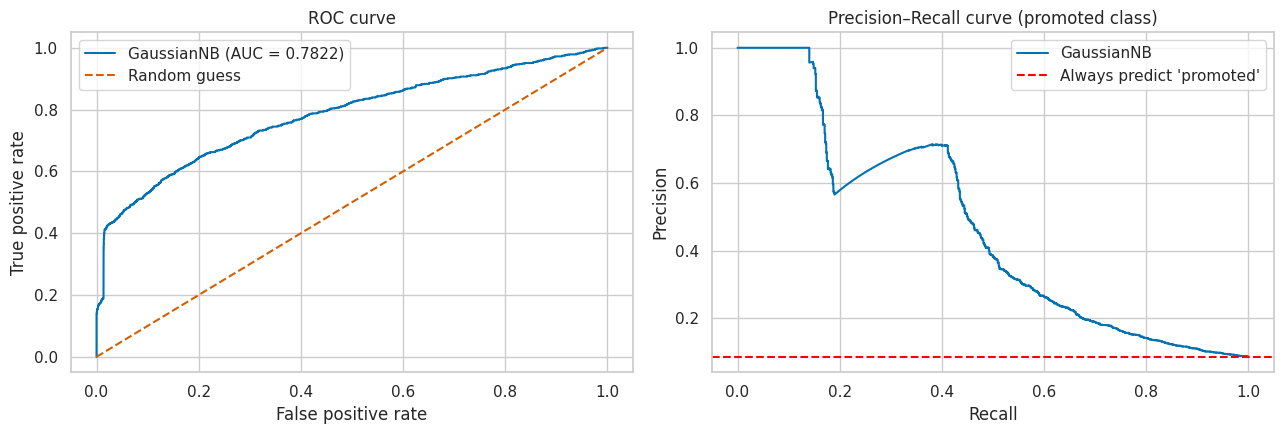

In [27]:
# ---- 3.10 ROC and Precision-Recall curves ----
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(fpr, tpr, label=f"GaussianNB (AUC = {tuned_scores['ROC_AUC']:.4f})")
axes[0].plot([0, 1], [0, 1], "r--", label="Random guess")
axes[0].set_title("ROC curve"); axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].legend()

axes[1].plot(rec, prec, label="GaussianNB")
axes[1].axhline(y_test.mean(), color="red", linestyle="--", label="Always predict 'promoted'")
axes[1].set_title("Precision–Recall curve (promoted class)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend()
plt.tight_layout(); plt.show()

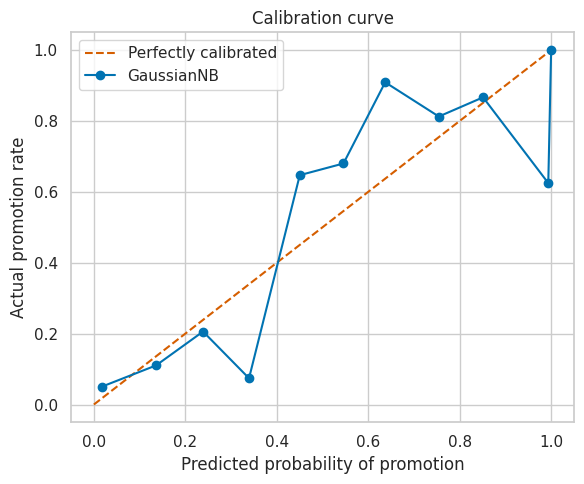

Brier score (lower is better): 0.0622

How many test employees fall in each probability band:
     mean_predicted  actual_rate     n
bin                                   
0             0.017        0.050  9974
1             0.136        0.110   308
2             0.239        0.206    68
3             0.339        0.074    27
4             0.450        0.647    17
5             0.546        0.680    25
6             0.637        0.909    11
7             0.754        0.812    16
8             0.851        0.867    15
9             0.994        0.625   365
10            1.000        1.000    92


In [28]:
# ---- 3.11 Are the predicted probabilities trustworthy? ----
# Naive Bayes multiplies many correlated probabilities together, which pushes its outputs towards 0 and 1.
# A calibration curve compares predicted probability with the share of employees actually promoted.
bins = np.linspace(0, 1, 11)
bin_id = np.digitize(y_proba, bins) - 1
cal = pd.DataFrame({"bin": bin_id, "proba": y_proba, "actual": y_test.values}) \
        .groupby("bin").agg(mean_predicted=("proba", "mean"), actual_rate=("actual", "mean"), n=("actual", "size"))

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], "r--", label="Perfectly calibrated")
plt.plot(cal["mean_predicted"], cal["actual_rate"], "o-", label="GaussianNB")
plt.title("Calibration curve")
plt.xlabel("Predicted probability of promotion"); plt.ylabel("Actual promotion rate")
plt.legend(); plt.tight_layout(); plt.show()

print("Brier score (lower is better): %.4f" % brier_score_loss(y_test, y_proba))
print("\nHow many test employees fall in each probability band:")
print(cal.round(3))

**📝 What this shows:** The probabilities are not trustworthy as real chances, so use them only to rank employees, not to read as percentages.

Default threshold (0.50)  -> F1 (promoted) = 0.5120
Best threshold (0.4003)  -> F1 (promoted) = 0.5210


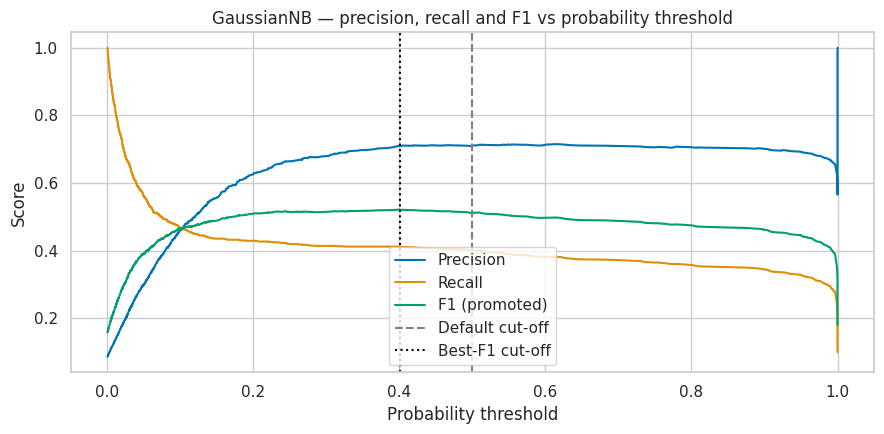

In [29]:
# ---- 3.12 Moving the decision threshold ----
f1s = 2 * prec * rec / np.maximum(prec + rec, 1e-9)
best_t = thresholds[np.argmax(f1s[:-1])]
print("Default threshold (0.50)  -> F1 (promoted) = %.4f" % f1_score(y_test, (y_proba >= 0.5).astype(int)))
print("Best threshold (%.4f)  -> F1 (promoted) = %.4f" % (best_t, f1_score(y_test, (y_proba >= best_t).astype(int))))

plt.figure(figsize=(9, 4.5))
plt.plot(thresholds, prec[:-1], label="Precision")
plt.plot(thresholds, rec[:-1], label="Recall")
plt.plot(thresholds, f1s[:-1], label="F1 (promoted)")
plt.axvline(0.5, color="grey", linestyle="--", label="Default cut-off")
plt.axvline(best_t, color="black", linestyle=":", label="Best-F1 cut-off")
plt.title("GaussianNB — precision, recall and F1 vs probability threshold")
plt.xlabel("Probability threshold"); plt.ylabel("Score")
plt.legend(); plt.tight_layout(); plt.show()

In [30]:
# ---- 3.13 5-fold stratified cross-validation ----
cv_scores = cross_val_score(GaussianNB(**best_params), X_train_p, y_train, cv=skf, scoring="f1")
print("CV F1 (promoted) per fold:", np.round(cv_scores, 4))
print(f"Mean CV F1: {cv_scores.mean():.4f}  (± {cv_scores.std():.4f})")

acc_scores = cross_val_score(GaussianNB(**best_params), X_train_p, y_train, cv=skf, scoring="accuracy")
print("Mean CV accuracy: %.4f" % acc_scores.mean())

CV F1 (promoted) per fold: [0.4659 0.5064 0.4801 0.4905 0.4877]
Mean CV F1: 0.4861  (± 0.0132)
Mean CV accuracy: 0.9319


In [31]:
# ---- 3.14 Save results for the Part-A comparison table ----
os.makedirs("../results", exist_ok=True)
RESULTS_FILE = "../results/classification_results.csv"
MODEL_NAME = "Naive Bayes (Gaussian)"

row = pd.DataFrame([{
    "Model": MODEL_NAME,
    **tuned_scores,
    "CV_F1_promoted": cv_scores.mean(),
    "Tuned": "Yes (GridSearchCV)",
    "Best_params": str(best_params),
}])
if os.path.exists(RESULTS_FILE):
    old = pd.read_csv(RESULTS_FILE)
    row = pd.concat([old[old["Model"] != MODEL_NAME], row], ignore_index=True)
row.to_csv(RESULTS_FILE, index=False)
row.round(4)

,Model,Accuracy,F1_weighted,Precision_weighted,Recall_weighted,F1_promoted,Recall_promoted,ROC_AUC,CV_F1_promoted,Tuned,Best_params
0,Support Vector Machine (SVC),0.9416,0.9289,0.9409,0.9416,0.5000,0.3419,0.7517,0.4794,Yes (GridSearchCV),"{'C': 10, 'class_weight': None, 'gamma': 'scal..."
1,Logistic Regression,0.9395,0.9249,0.9407,0.9395,0.4634,0.3055,0.7897,0.4494,Yes (GridSearchCV),"{'C': 1, 'class_weight': None, 'penalty': 'l2'..."
2,Naive Bayes (Gaussian),0.9349,0.9264,0.9261,0.9349,0.5120,0.3998,0.7822,0.4861,Yes (GridSearchCV),{'var_smoothing': 0.1}


## Summary

**📝 In short:** Naive Bayes trains in 0.03 seconds and finds the most promotions (40%), but its probability numbers cannot be trusted.